(mmm_media_inflation)=

# We spent more. We bought fewer ads.

*When the currency of your media input drifts, MMM attribution breaks even if in-sample fit looks fine.*

Finance has three years of weekly numbers on the table. Nominal paid-social spend is up. Sales are roughly flat. The working theory is that paid media "isn't working like it used to."

Maybe. Or maybe each dollar simply bought fewer ads while CPMs crept up faster than the budget. In this notebook we fit the usual MMM on **nominal spend**, watch a flexible **trend** component absorb the unit error, then deflate spend to **today's dollars** and compare attribution against planted truth.

```{note}
**Prerequisites.** You should have worked through {ref}`mmm_quickstart` or {ref}`mmm_example` and be able to build and fit an `MMM`. This notebook adds preprocessing for media unit drift; it does not re-teach the core workflow.

**Best path when you have delivery data.** If every channel gives you impressions or GRPs, fit on those native units and report in currency with {ref}`mmm_cost_per_unit`. This notebook is the spend-only path: a media-cost index, applied before `fit`.
```

```{warning}
**Slow index, not noisy weekly CPM.** Deflating spend removes a *multi-year* unit trend. It is not the same as multiplying impressions by volatile weekly auction prices and putting that into $X$. Use a smooth annual or quarterly media-cost index; see {ref}`mmm_cost_per_unit` for why week-to-week price noise belongs out of the predictor.
```

We use **simulated data with a known data-generating process** so every fit can be reality-checked. Econometricians and platform analysts have tracked media inflation for decades; the value here is making the **attribution failure mode visible** inside an MMM, not claiming to discover the problem.


## Prepare notebook

In [1]:
import arviz as az
import graphviz as gr
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm import GeometricAdstock, LinearTrend, LogisticSaturation
from pymc_marketing.mmm.additive_effect import LinearTrendEffect
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")

FIG_WIDTH = 12
FIG_HEIGHT = 7
plt.rcParams["figure.figsize"] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["figure.dpi"] = 100

COLOR_CPM = "#E76F51"
COLOR_SPEND = "#2A9D8F"
COLOR_IMPRESSIONS = "#E9C46A"
COLOR_Y = "#1D3557"
COLOR_MEDIA = "#264653"
COLOR_TREND = "#9B5DE5"

CHANNEL = "paid_social"
ANNUAL_CPM_INFLATION = 0.08
ANNUAL_SPEND_GROWTH = 0.03
WEEKS_PER_YEAR = 52.0

%config InlineBackend.figure_format = "retina"

%load_ext autoreload
%autoreload 2


def style_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.35)
    ax.grid(True, which="minor", axis="x", linestyle=":", alpha=0.2)

In [2]:
seed = sum(map(ord, "media inflation"))
rng = np.random.default_rng(seed=seed)

FIT_KWARGS = {
    "nuts_sampler": "nutpie",
    "target_accept": 0.9,
    "chains": 4,
    "draws": 500,
    "tune": 500,
    "random_seed": rng,
}

## The data: what the ledger shows vs what was bought

The planted world is small on purpose: one market, one paid channel, 156 weeks. No extra geos, no controls. A few-changepoint {class}`~pymc_marketing.mmm.linear_trend.LinearTrend` is the time-varying base in every fit below. The intercept is **constant**; we are not using `time_varying_intercept=True` (HSGP) because it is slower and would soak up unit drift even more aggressively (see the callout in Analysis 1).

**Causal ground truth (known before any fit):**

- **Nominal spend** is what finance reports. It grows at **3% per year**: modest budget uplifts, typical when marketing gets annual increases below auction inflation.
- **CPM** compounds at **8% per year** (~26% over three years). Platform benchmarks often cite roughly **5–12%** year-on-year CPM growth in mature digital channels during normal periods.
- **Impressions** are the dose: `impressions ∝ spend / CPM`. Because CPM rises faster than spend, **delivery falls** (~15% over the window) aside from campaign flighting. Offline TV uses the same logic with **GRPs** and cost-per-GRP.
- **True media contribution** therefore **drifts down gently** with impressions. That decline is planted in $y$, not a model output.
- **Baseline demand** (intercept) is **constant**. No real organic growth trend.
- **Seasonality** shifts sales on a mild yearly calendar cycle.
- **Sales** are intercept + seasonality + adstock/saturation(**impressions**) + noise, so $y$ stays roughly **flat** even as nominal spend rises.

Some teams index budgets to inflation so spend and CPM rise together and delivery stays flat; the unit problem is quieter there but still present. Here we use the more alarming, still common case: **spend up, impressions down**.

The diagram is that world. The first MMM fit only receives **date, nominal spend, and sales**. Impressions and CPM are hidden validation columns.


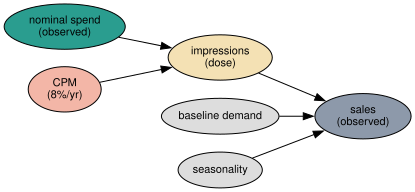

In [3]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.attr("node", fontname="Helvetica", fontsize="11")

g.node("spend", "nominal spend\n(observed)", style="filled", fillcolor="#2A9D8F")
g.node(
    "cpm",
    f"CPM\n({ANNUAL_CPM_INFLATION:.0%}/yr)",
    style="filled",
    fillcolor="#E76F5180",
)
g.node("impressions", "impressions\n(dose)", style="filled", fillcolor="#E9C46A80")
g.node("baseline", "baseline demand", style="filled", fillcolor="#dddddd")
g.node("season", "seasonality", style="filled", fillcolor="#dddddd")
g.node("y", "sales\n(observed)", style="filled", fillcolor="#1D355780")

with g.subgraph() as inputs:
    inputs.attr(rank="same")
    inputs.node("spend")
    inputs.node("cpm")

g.edge("spend", "impressions")
g.edge("cpm", "impressions")
g.edge("impressions", "y")
g.edge("baseline", "y")
g.edge("season", "y")
g

The next cell simulates this world. Nominal spend and CPM jointly determine impressions; impressions, baseline demand, and seasonality jointly determine sales.


In [4]:
def geometric_adstock_np(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    weights = alpha ** np.arange(l_max)
    return np.convolve(x, weights, mode="full")[: len(x)]


def logistic_saturation_np(x: np.ndarray, lam: float) -> np.ndarray:
    return (1.0 - np.exp(-lam * x)) / (1.0 + np.exp(-lam * x))


n_weeks = 156
dates = pd.date_range("2023-01-02", periods=n_weeks, freq="W-MON")
years_elapsed = np.arange(n_weeks) / WEEKS_PER_YEAR

flight = 0.45 + 0.55 * ((np.arange(n_weeks) % 10) < 6).astype(float)
cpm_factor = (1.0 + ANNUAL_CPM_INFLATION) ** years_elapsed
spend_factor = (1.0 + ANNUAL_SPEND_GROWTH) ** years_elapsed

cpm = 10.0 * cpm_factor
spend = 5_000.0 * spend_factor * flight * (1.0 + 0.05 * rng.normal(size=n_weeks))
spend = np.clip(spend, 1.0, None)
impressions = spend * 1_000.0 / cpm

imp_scaled = impressions / impressions.max()
adstocked = geometric_adstock_np(imp_scaled, alpha=0.4, l_max=8)
media_true = 1_200.0 * logistic_saturation_np(adstocked, lam=2.5)

intercept_true = 2_000.0
season = 80.0 * np.sin(2.0 * np.pi * dates.dayofyear.to_numpy() / 365.25)
y = intercept_true + media_true + season + rng.normal(0.0, 40.0, size=n_weeks)

df = pd.DataFrame(
    {
        "date": dates,
        CHANNEL: spend,
        "impressions": impressions,
        "cpm": cpm,
        "y": y,
        "media_true": media_true,
    }
)

The ledger finance is staring at is date, spend, and sales. First and last weeks:


In [5]:
ledger = df.set_index("date")[[CHANNEL, "y"]]
ledger.iloc[[0, -1]]

,paid_social,y
date,,
2023-01-02,5270.306658,3007.224720
2025-12-22,5557.574089,3104.139005


Spend is up; sales are not. The hidden columns (CPM and impressions) explain why. First and last weeks:


In [6]:
hidden = df.set_index("date")[["cpm", "impressions", CHANNEL, "y"]]
hidden.iloc[[0, -1]]

,cpm,impressions,paid_social,y
date,,,,
2023-01-02,10.00000,527030.665831,5270.306658,3007.224720
2025-12-22,12.57849,441831.585321,5557.574089,3104.139005


Nominal spend rises because marketing gets modest annual uplifts (+3%/year) while CPM rises faster (+8%/year), so impressions fall. Sales do not follow spend. The next figure indexes both series to week 1 (= 100) so the divergence is easy to see.


**Caption:** Nominal paid-social spend and impressions indexed to week 1 (= 100). Spend rises with budget uplifts; impressions fall because CPM outpaces spend growth.


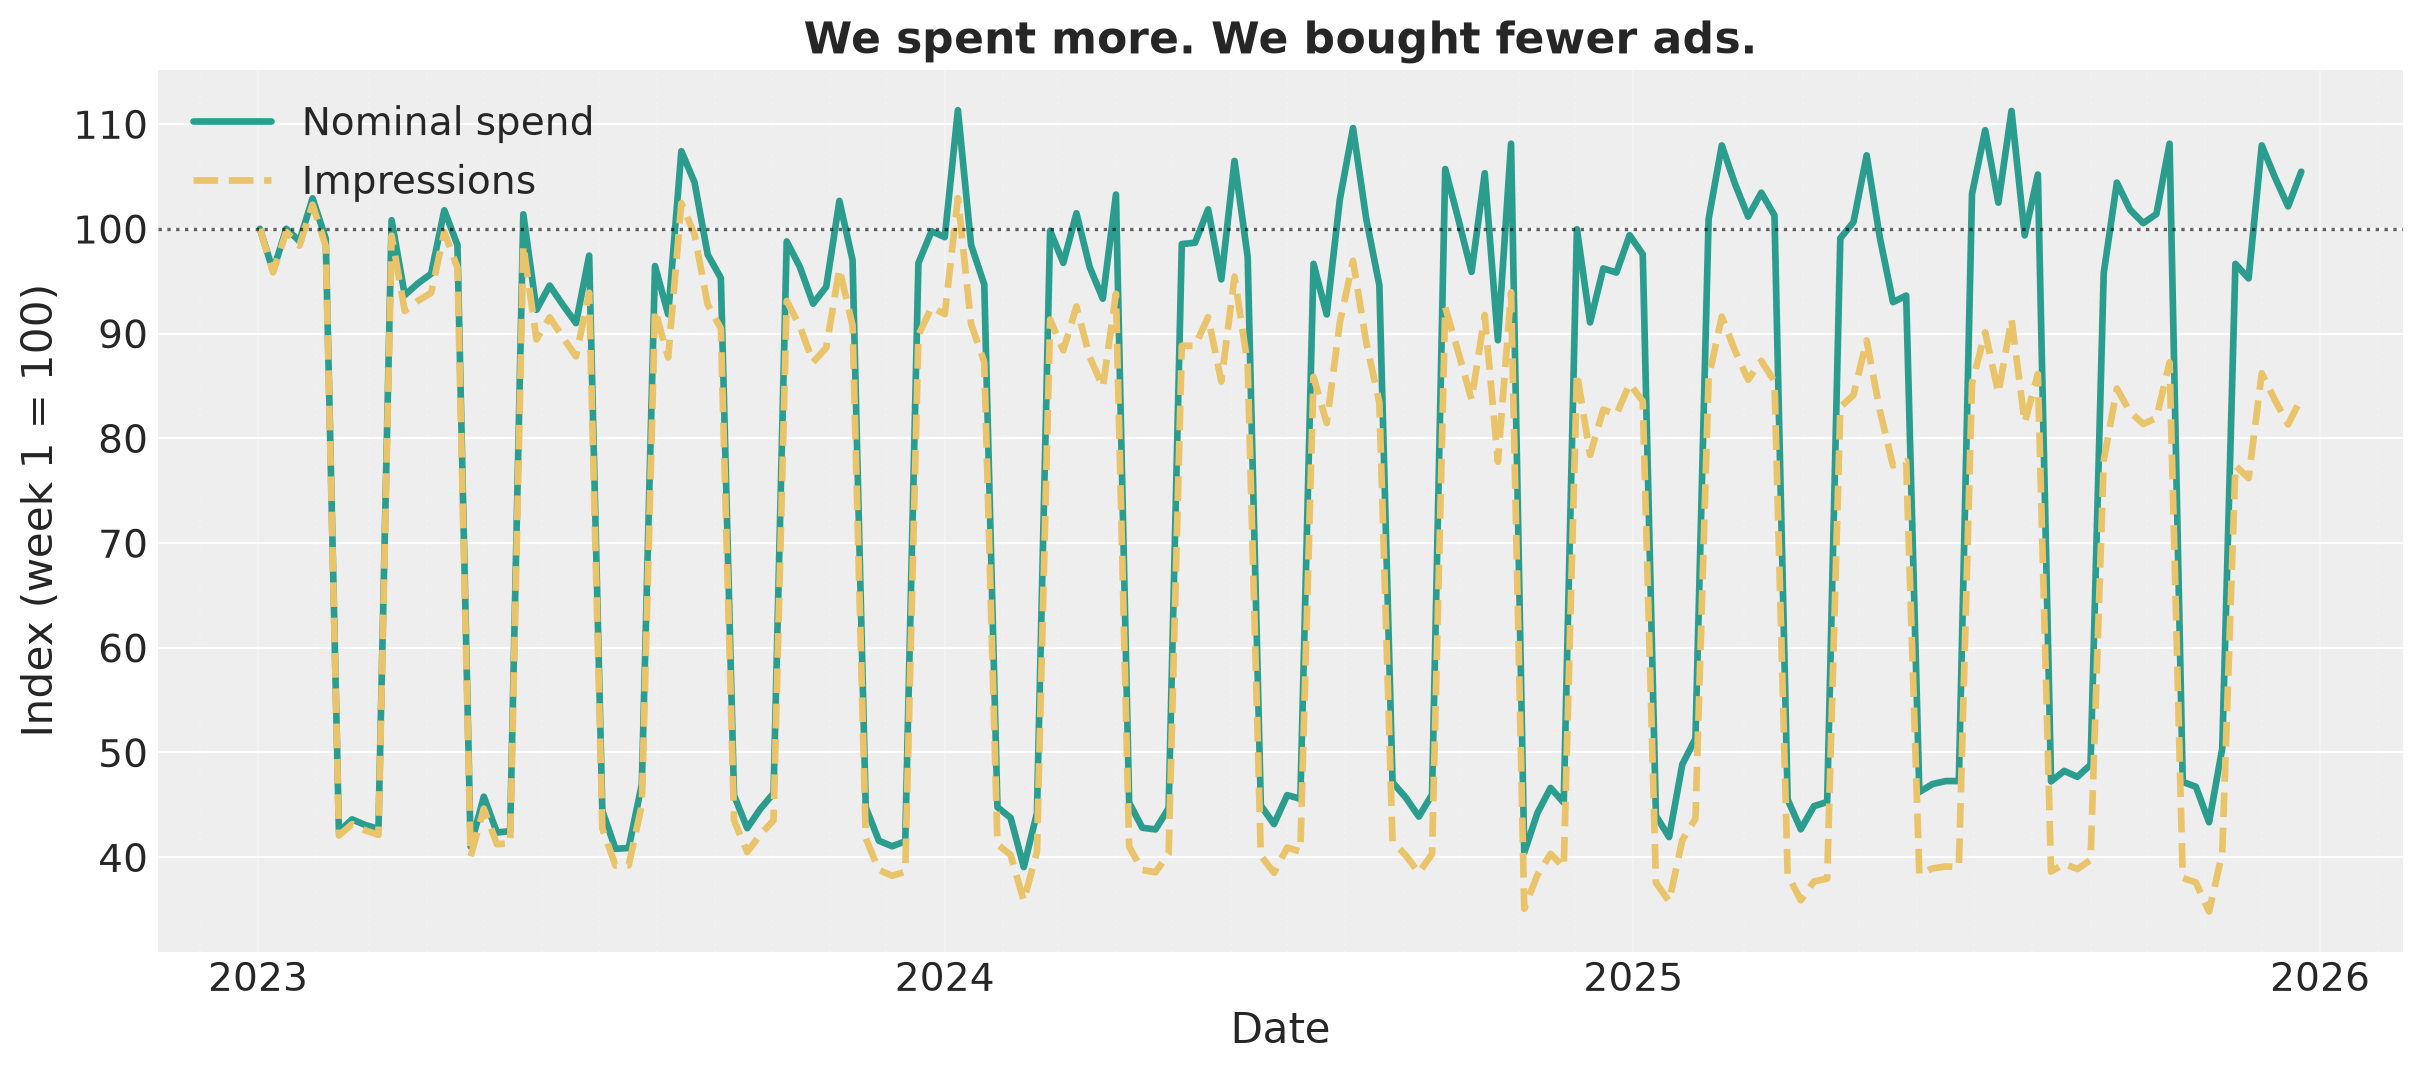

In [7]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.75))
spend_index = 100.0 * df[CHANNEL] / df[CHANNEL].iloc[0]
imp_index = 100.0 * df["impressions"] / df["impressions"].iloc[0]
ax.plot(
    df["date"], spend_index, color=COLOR_SPEND, linewidth=2.4, label="Nominal spend"
)
ax.plot(
    df["date"],
    imp_index,
    color=COLOR_IMPRESSIONS,
    linewidth=2.4,
    linestyle="--",
    label="Impressions",
)
ax.axhline(100.0, color="black", linestyle=":", linewidth=1.2, alpha=0.6)
ax.set_ylabel("Index (week 1 = 100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.set_title("We spent more. We bought fewer ads.", fontsize=16, fontweight="bold")
style_date_axis(ax)
plt.show()

**Caption:** Weekly CPM ($), nominal paid-social spend ($), impressions, and sales over 156 weeks. CPM rises faster than spend; impressions trend down; sales stay roughly flat aside from flighting and mild seasonality.


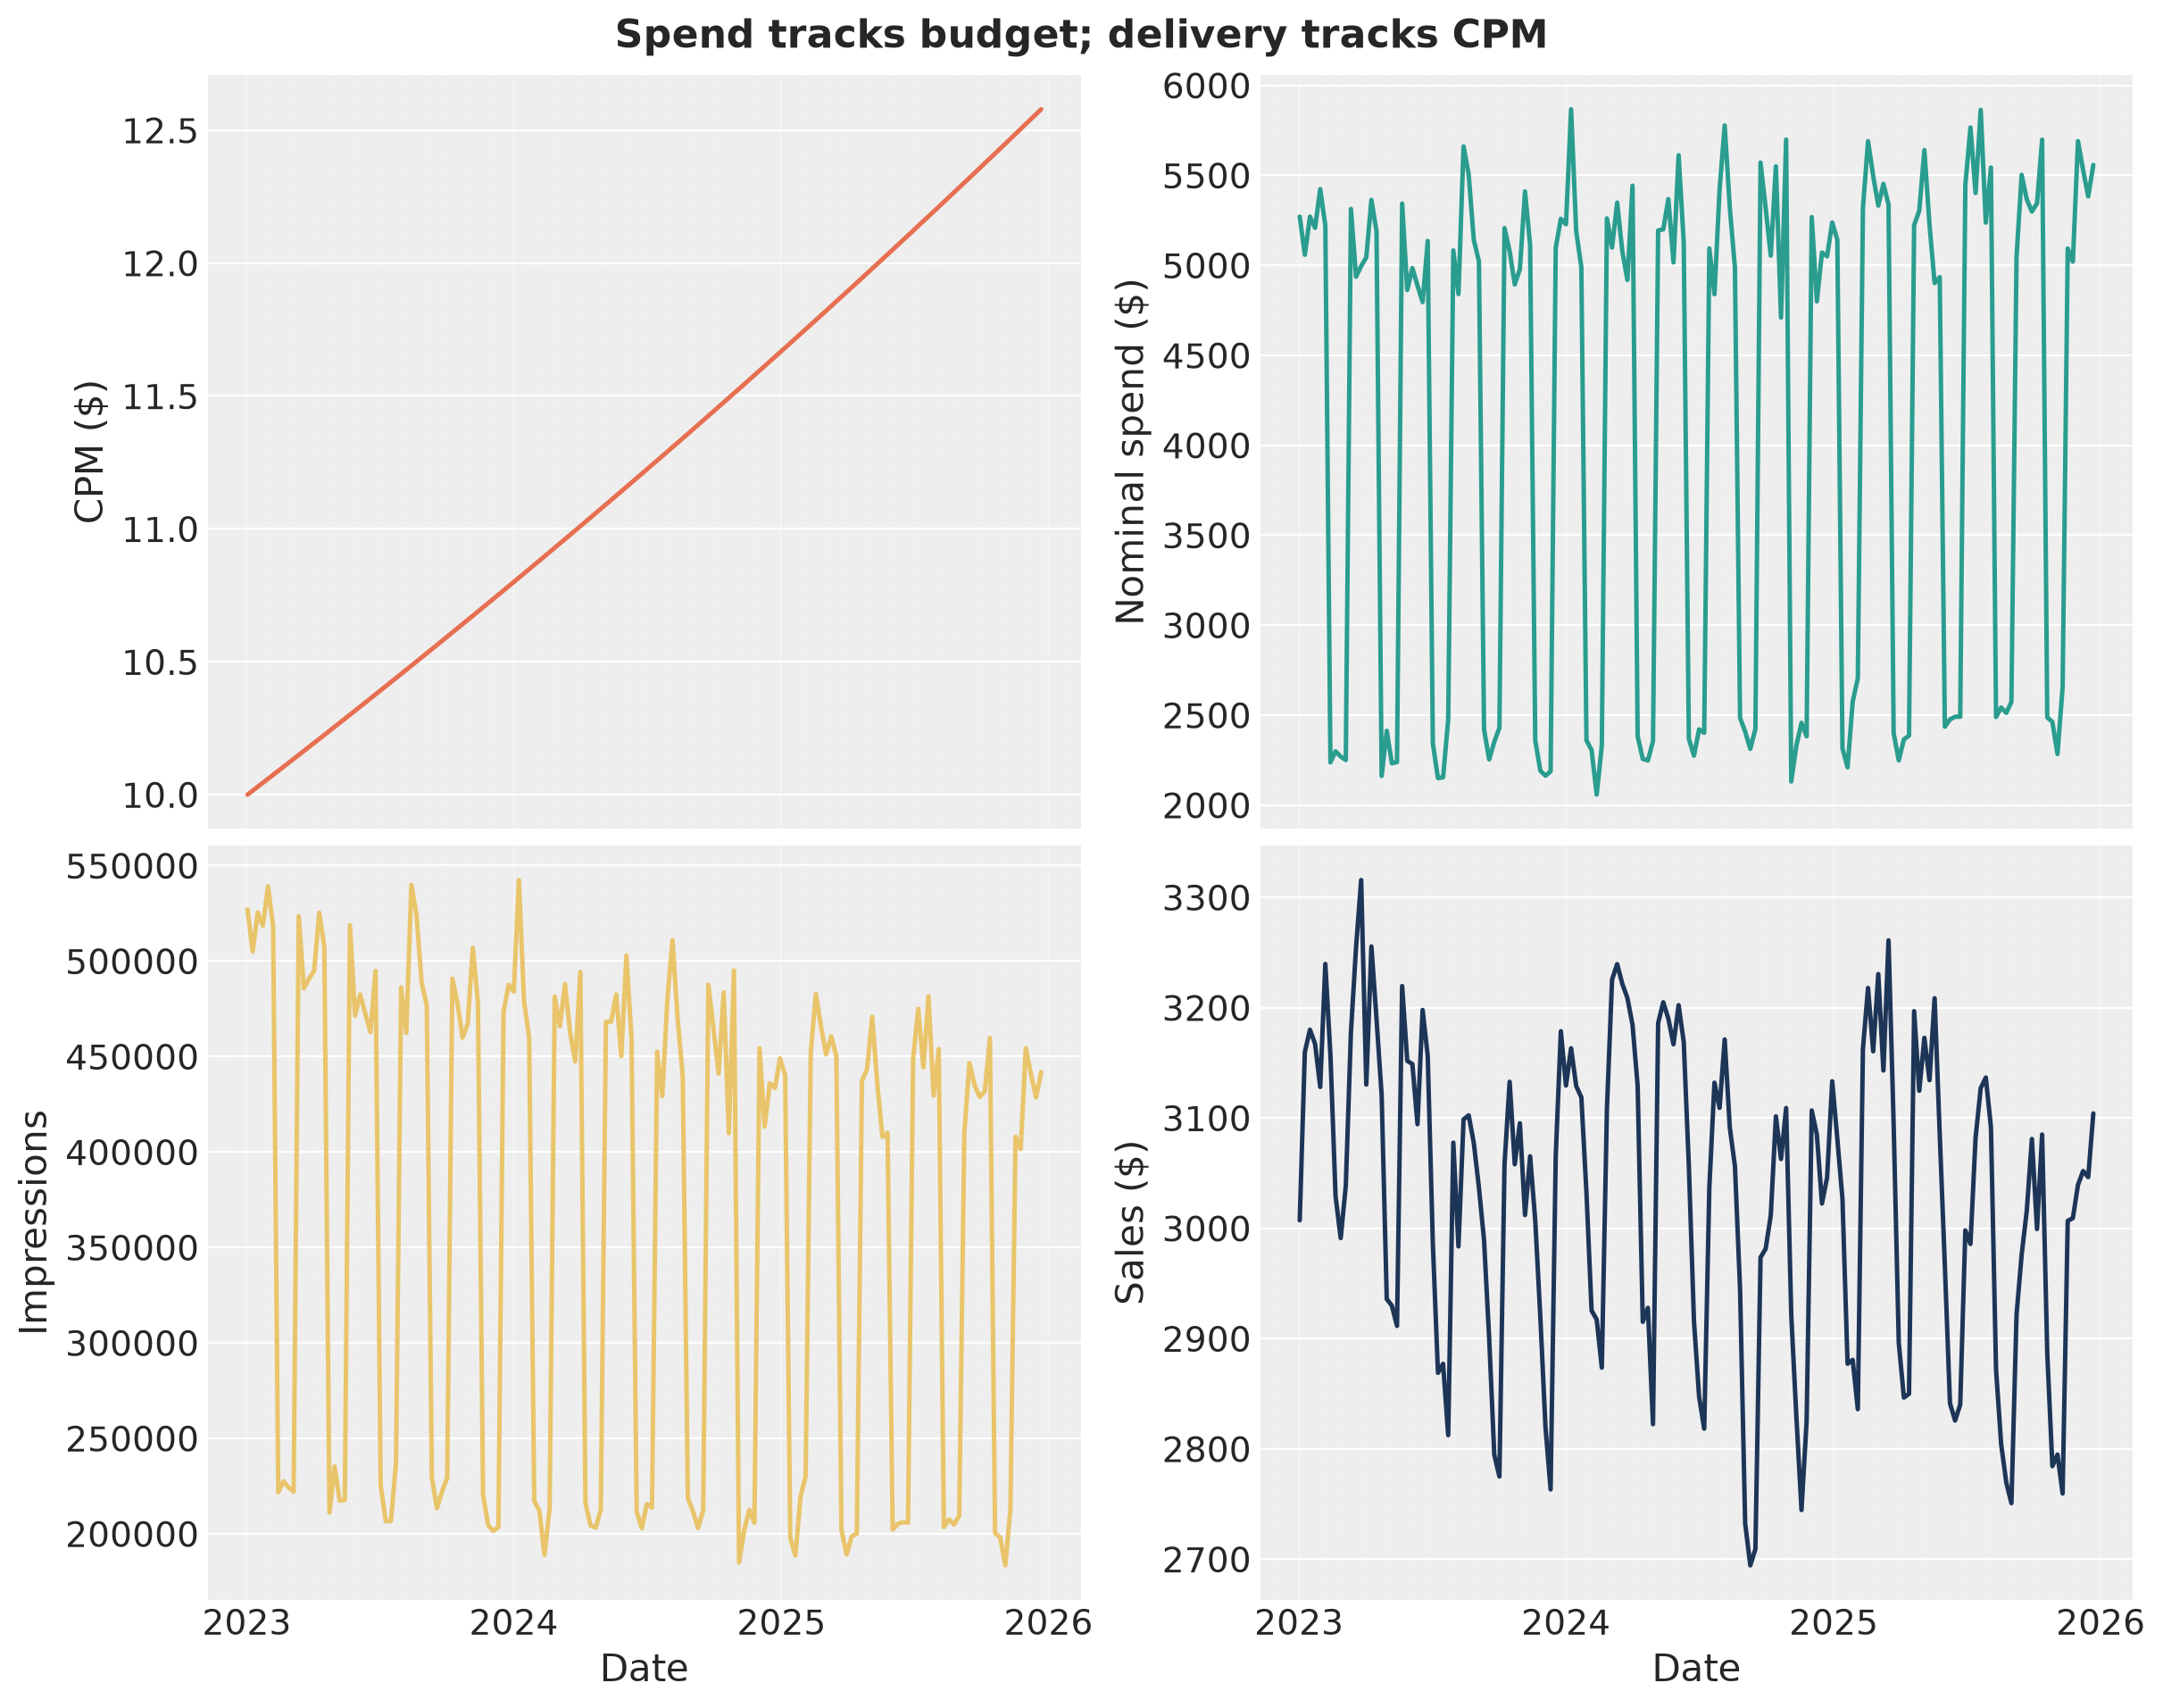

In [8]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
    sharex=True,
)

series = [
    (axes[0, 0], "cpm", "CPM ($)", COLOR_CPM),
    (axes[0, 1], CHANNEL, "Nominal spend ($)", COLOR_SPEND),
    (axes[1, 0], "impressions", "Impressions", COLOR_IMPRESSIONS),
    (axes[1, 1], "y", "Sales ($)", COLOR_Y),
]
for ax, col, ylabel, color in series:
    ax.plot(df["date"], df[col], color=color, linewidth=1.8)
    ax.set_ylabel(ylabel)
    style_date_axis(ax)

axes[1, 0].set_xlabel("Date")
axes[1, 1].set_xlabel("Date")
fig.suptitle("Spend tracks budget; delivery tracks CPM", fontsize=16, fontweight="bold")
plt.show()

The naive reading writes itself: we spent more and got nothing. The next section fits that reading as an MMM on nominal dollars.


## Analysis 1: fit on nominal spend

Same specification we reuse in every analysis below: geometric adstock, logistic saturation, yearly seasonality, and a {class}`~pymc_marketing.mmm.additive_effect.LinearTrendEffect` with a handful of changepoints via {meth}`~pymc_marketing.mmm.mmm.MMM.add_mu_effect`. Only $X$ changes later.

We do **not** set `time_varying_intercept=True`. An HSGP intercept is too slow for this fundamentals notebook, and it is an even more flexible sponge for slow unit drift than `LinearTrend`.

```{warning}
If your production MMM uses `time_varying_intercept=True`, CPM drift can be absorbed into the intercept just as easily (often more easily) than into an explicit trend. Deflating the media input is still preprocessing; a flexible baseline is not a substitute.
```


In [9]:
def fit_mmm(X: pd.DataFrame, y: pd.Series) -> MMM:
    mmm = MMM(
        date_column="date",
        channel_columns=[CHANNEL],
        target_column="y",
        adstock=GeometricAdstock(l_max=8),
        saturation=LogisticSaturation(),
        yearly_seasonality=2,
    )
    mmm.add_mu_effect(
        LinearTrendEffect(
            trend=LinearTrend(n_changepoints=3),
            prefix="trend",
        )
    )
    mmm.fit(X, y, **FIT_KWARGS)
    return mmm


def plot_posterior_band(
    ax, dates, da, color, label, alpha=0.3, linewidth=2.5, line_alpha=1.0
):
    hdi = az.hdi(da, prob=0.94)
    ax.fill_between(
        dates,
        np.asarray(hdi.sel(ci_bound="lower")).squeeze(),
        np.asarray(hdi.sel(ci_bound="upper")).squeeze(),
        color=color,
        alpha=alpha,
        zorder=1,
    )
    ax.plot(
        dates,
        da.mean(("chain", "draw")).to_numpy().squeeze(),
        color=color,
        linewidth=linewidth,
        alpha=line_alpha,
        label=label,
        zorder=3,
    )


def plot_media_vs_trend(ds, dates, media_true, ylim_media, ylim_trend, title):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
        sharex=True,
    )
    plot_posterior_band(axes[0], dates, ds[CHANNEL], COLOR_MEDIA, "Fitted media")
    axes[0].plot(
        dates,
        media_true,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="True media",
        zorder=5,
    )
    axes[0].set_ylabel("Media contribution ($)")
    axes[0].legend(loc="upper left")
    axes[0].set_ylim(ylim_media)

    plot_posterior_band(axes[1], dates, ds["trend_effect"], COLOR_TREND, "Fitted trend")
    axes[1].axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="True trend (0)",
        zorder=5,
    )
    axes[1].set_ylabel("Trend contribution ($)")
    axes[1].set_xlabel("Date")
    axes[1].legend(loc="upper left")
    axes[1].set_ylim(ylim_trend)
    style_date_axis(axes[1])

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.show()
    return fig, axes


def mean_by_year(da, dates: pd.Series) -> pd.Series:
    s = da.mean(("chain", "draw")).to_series()
    s.index = pd.to_datetime(dates.to_numpy())
    return s.groupby(s.index.year).mean()


def half_window_slope(x) -> float:
    values = np.asarray(x).squeeze()
    half = len(values) // 2
    return float(values[-half:].mean() - values[:half].mean())

In [10]:
X_nominal = df[["date", CHANNEL]].copy()
y = df["y"]

mmm_nominal = fit_mmm(X_nominal, y)
ds_nominal = mmm_nominal.compute_counterfactual_contributions_dataset()

NUTS[nutpie]: [delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, y_sigma]


Output()

Output()

Contributions are on the original scale of $y$, via {meth}`~pymc_marketing.mmm.mmm.MMM.compute_counterfactual_contributions_dataset`. The black dashed line is the planted media contribution (gentle decline with delivery; flighting visible week to week), not a model output.


In [11]:
hdi_media = az.hdi(ds_nominal[CHANNEL], prob=0.94)
hdi_trend = az.hdi(ds_nominal["trend_effect"], prob=0.94)
ylim_media = (
    0.0,
    max(
        float(np.asarray(hdi_media.sel(ci_bound="upper")).max()),
        1.25 * float(df["media_true"].max()),
    ),
)
pad_media = 0.08 * ylim_media[1]
ylim_media = (0.0, ylim_media[1] + pad_media)

ylim_trend = (
    min(float(np.asarray(hdi_trend.sel(ci_bound="lower")).min()), 0.0),
    max(float(np.asarray(hdi_trend.sel(ci_bound="upper")).max()), 0.0),
)
pad_trend = 0.08 * (ylim_trend[1] - ylim_trend[0])
ylim_trend = (ylim_trend[0] - pad_trend, ylim_trend[1] + pad_trend)

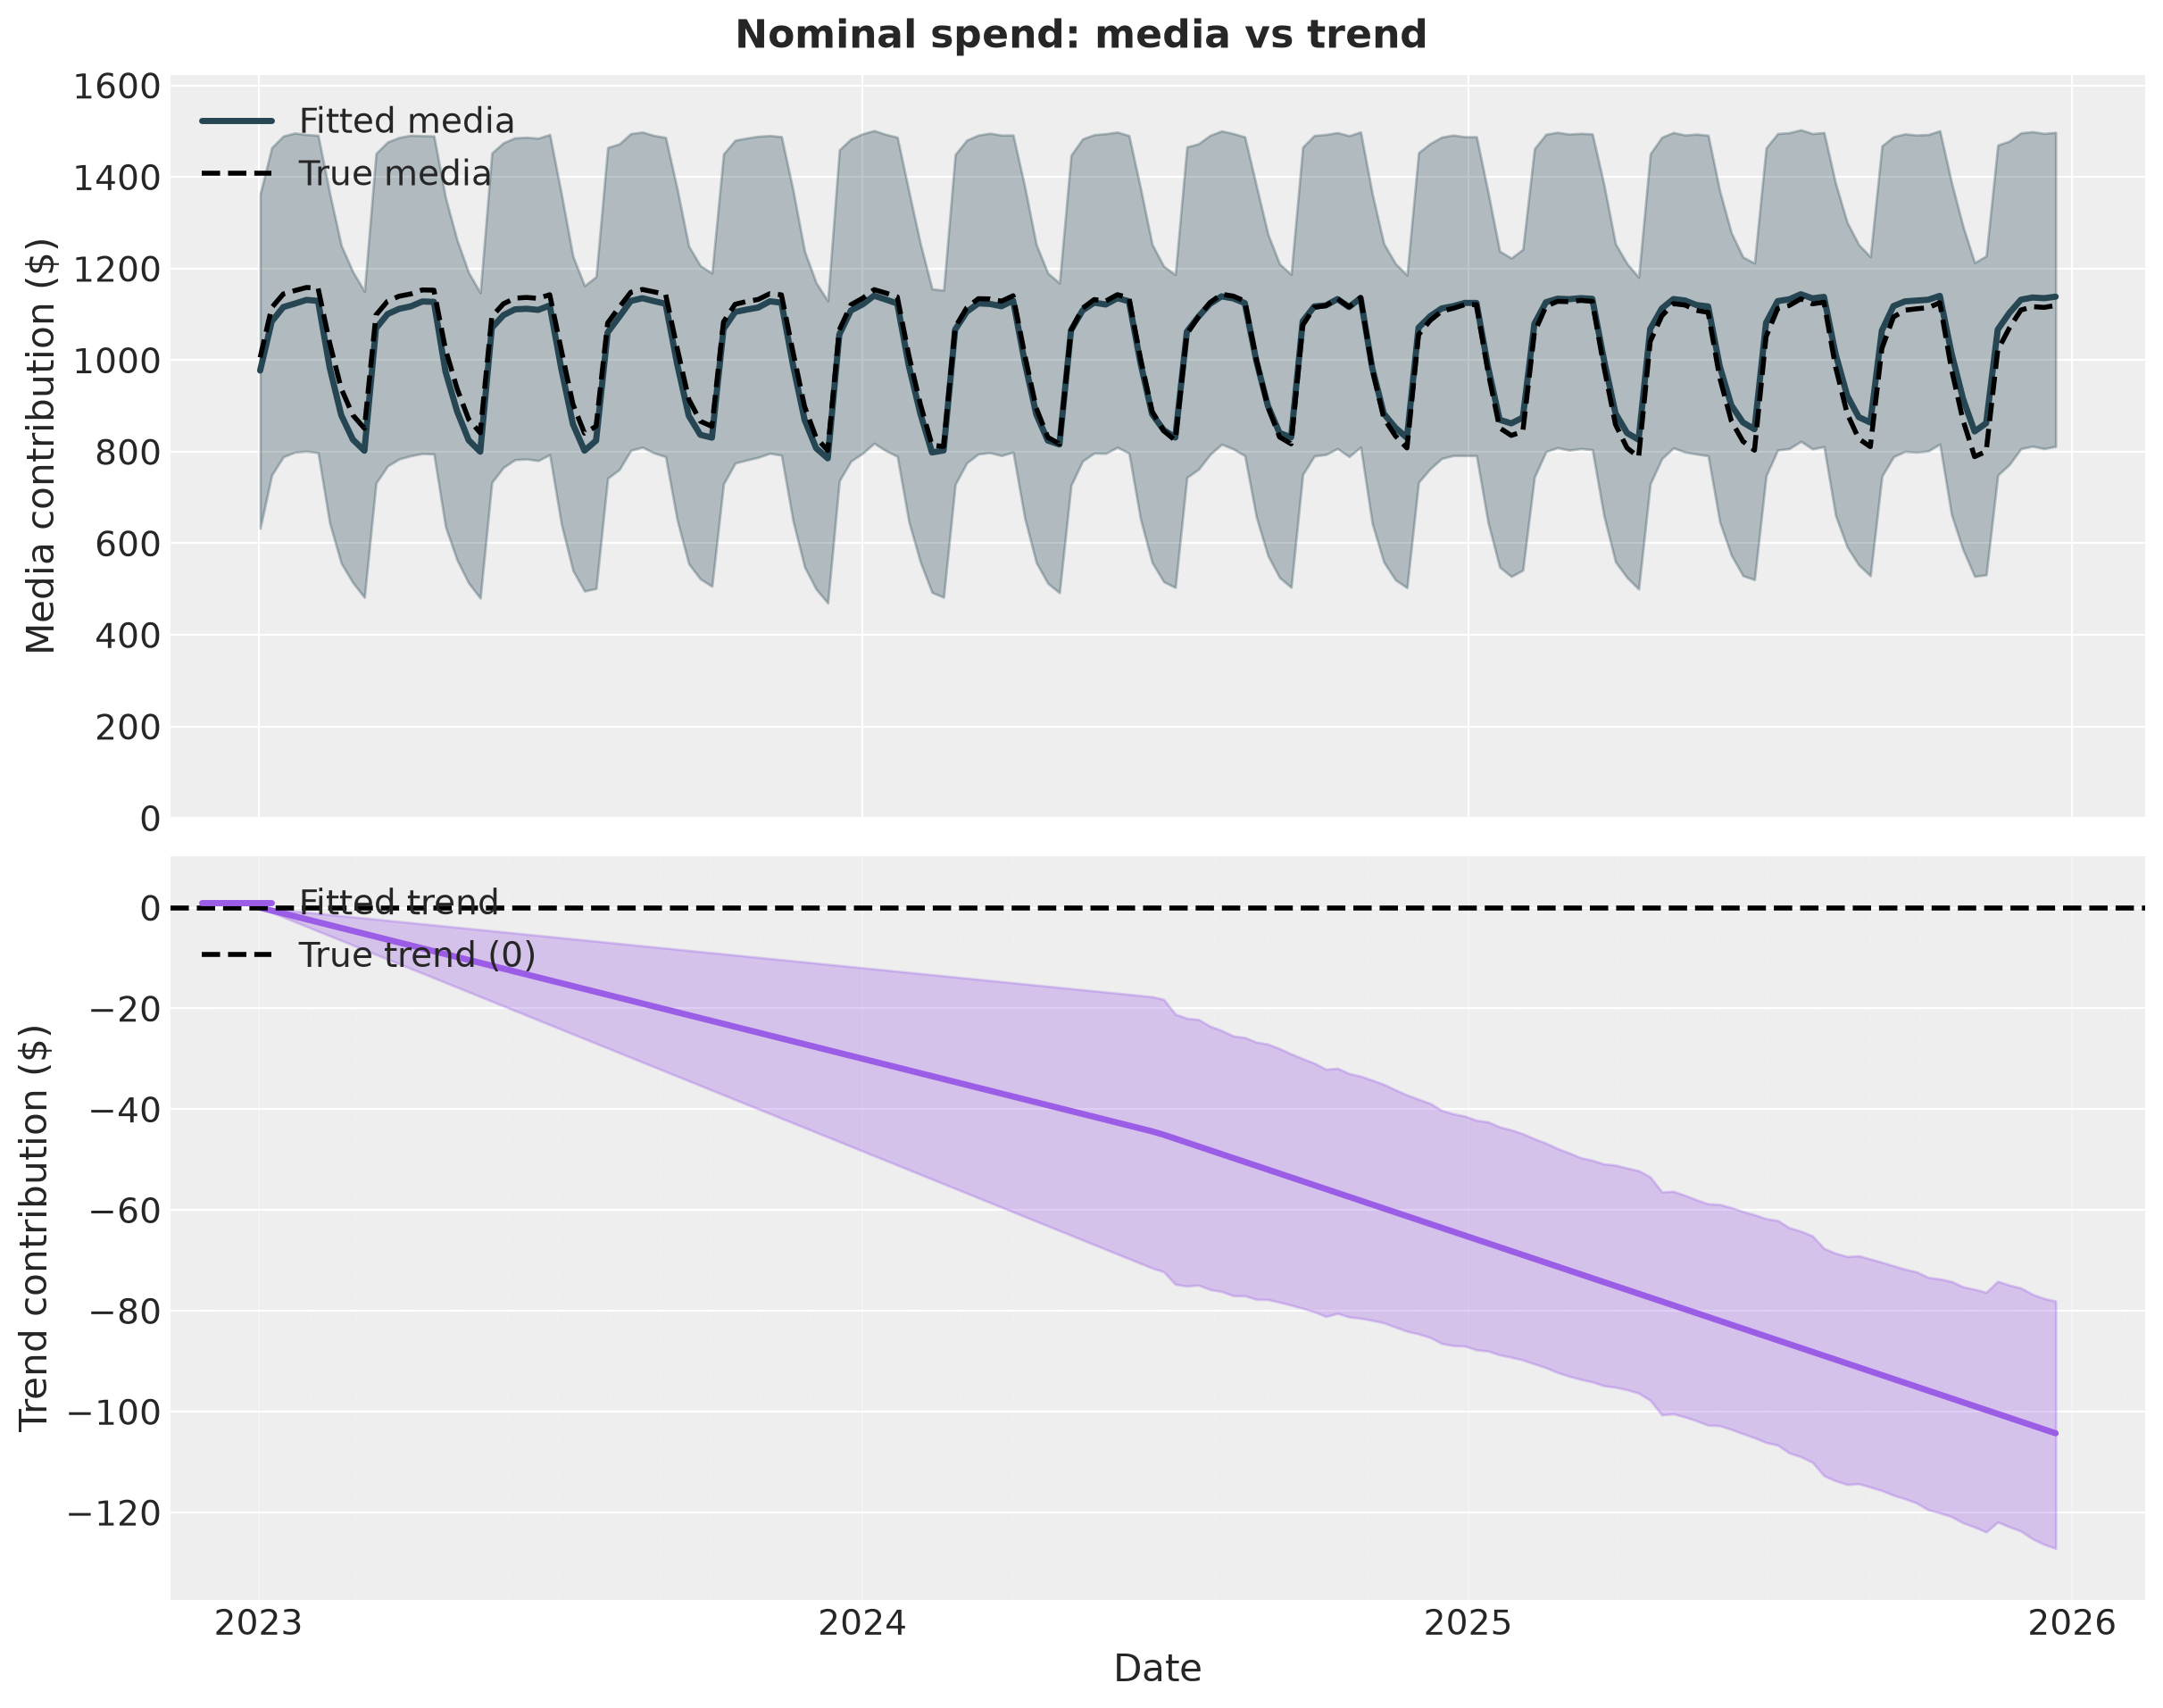

(<Figure size 1200x945 with 2 Axes>,
 array([<Axes: ylabel='Media contribution ($)'>,
        <Axes: xlabel='Date', ylabel='Trend contribution ($)'>],
       dtype=object))

In [12]:
plot_media_vs_trend(
    ds_nominal,
    df["date"],
    df["media_true"],
    ylim_media,
    ylim_trend,
    title="Nominal spend: media vs trend",
)

**Caption:** Posterior mean and 94% HDI for paid-social media contribution (top) and `LinearTrend` (bottom) when the MMM is fit on nominal spend. Black dashed: planted media contribution (top) and true trend of zero (bottom). Media panel y-axis starts at zero.


```{important}
**What the nominal-spend fit is doing.** Later weeks have **higher nominal spend** but **fewer impressions**. A time-invariant saturation curve maps those extra dollars to **rising** fitted media contribution (top panel). Planted media does the opposite: it **falls gently** with delivery (black dashed; flighting is the week-to-week wiggle). Sales did not rise, so the model **pulls trend contribution down** (bottom panel) to cancel. The mistaken read is "we spent more and got nothing, so the baseline is collapsing," with a unit error split between media and trend.
```

Before panicking about a collapsing baseline: in-sample fit can look fine. That is not the same as recovering the mechanism. Mean media contribution can even sit near the truth (**right for the wrong reasons**) because a rising media path and a falling trend cancel. The slope is the tell, not the average.


## Why $100 is not a stable input

Saturation and adstock are functions of the **media input**. If that input is nominal spend, the model treats "$100 of ads in 2023" as the same thing as "$100 of ads today." It is not: the later $100 bought fewer impressions.

Deflate to **today** (the last date in the sample), not to year one:

$$
I_t = \frac{p_t}{p_{\text{today}}}, \qquad x^{\text{today}}_t = \frac{x^{\text{nom}}_t}{I_t}.
$$

Then $x^{\text{today}}$ is in current dollars, which is proportional to impressions when $p_t$ tracks the cost of an impression.

```{important}
Calling {meth}`~pymc_marketing.mmm.mmm.MMM.set_cost_per_unit` on an already-fitted **spend** model only changes ROAS denominators. It does not rewrite the media input, so it does not fix this attribution. Deflate (or fit impressions) *before* `fit`.
```

```{warning}
Do not use time-varying *media* (`time_varying_media=True`) as an inflation sponge. That multiplier is for genuine efficiency changes. A unit drift in the currency of the predictor is preprocessing, not a latent GP.
```

```{note}
**What should you do in production?** Use the best data tier you have:

1. **Impressions or GRPs** → fit native units; report in dollars with {ref}`mmm_cost_per_unit`.
2. **Spend + CPM (or cost-per-GRP)** → reconstruct dose as `spend / smooth_CPM`, fit impressions, set `cost_per_unit` for reporting.
3. **Spend only** → deflate with an external media-cost index before `fit`; treat the index as an estimate and run sensitivity.

This notebook is tier 3. Tiers 1–2 live in {ref}`mmm_cost_per_unit`.
```


## Analysis 2: deflate spend

The transform is three lines. $p_t$ is a **smooth annual index**, not weekly CPM. Here we use the planted 8%/year as if it came from a platform benchmark or industry report. In production that rate is an estimate; run sensitivity on it (below).


In [13]:
years_elapsed = np.arange(len(X_nominal)) / WEEKS_PER_YEAR
index = (1.0 + ANNUAL_CPM_INFLATION) ** (years_elapsed - years_elapsed[-1])
X_today = X_nominal.copy()
X_today[CHANNEL] = X_nominal[CHANNEL] / index

X_today.head()

,date,paid_social
0,2023-01-02,6629.249855
1,2023-01-09,6353.275493
2,2023-01-16,6609.564460
3,2023-01-23,6522.233131
4,2023-01-30,6781.573722


```{tip}
A smooth annual or quarterly media-cost index is enough. Noisy weekly CPM is optional, and often worse: it puts auction jitter into the predictor. See the opening warning in this notebook.
```

If the deflator tracks the cost of an impression, today-dollar spend should overlay impressions (up to a scale). That is the "you did it right" plot.


**Caption:** Nominal paid-social spend ($/week), the same series divided by $I_t = p_t / p_{\text{today}}$, and impressions rescaled to the mean of the deflated series. Deflated spend overlays impressions.


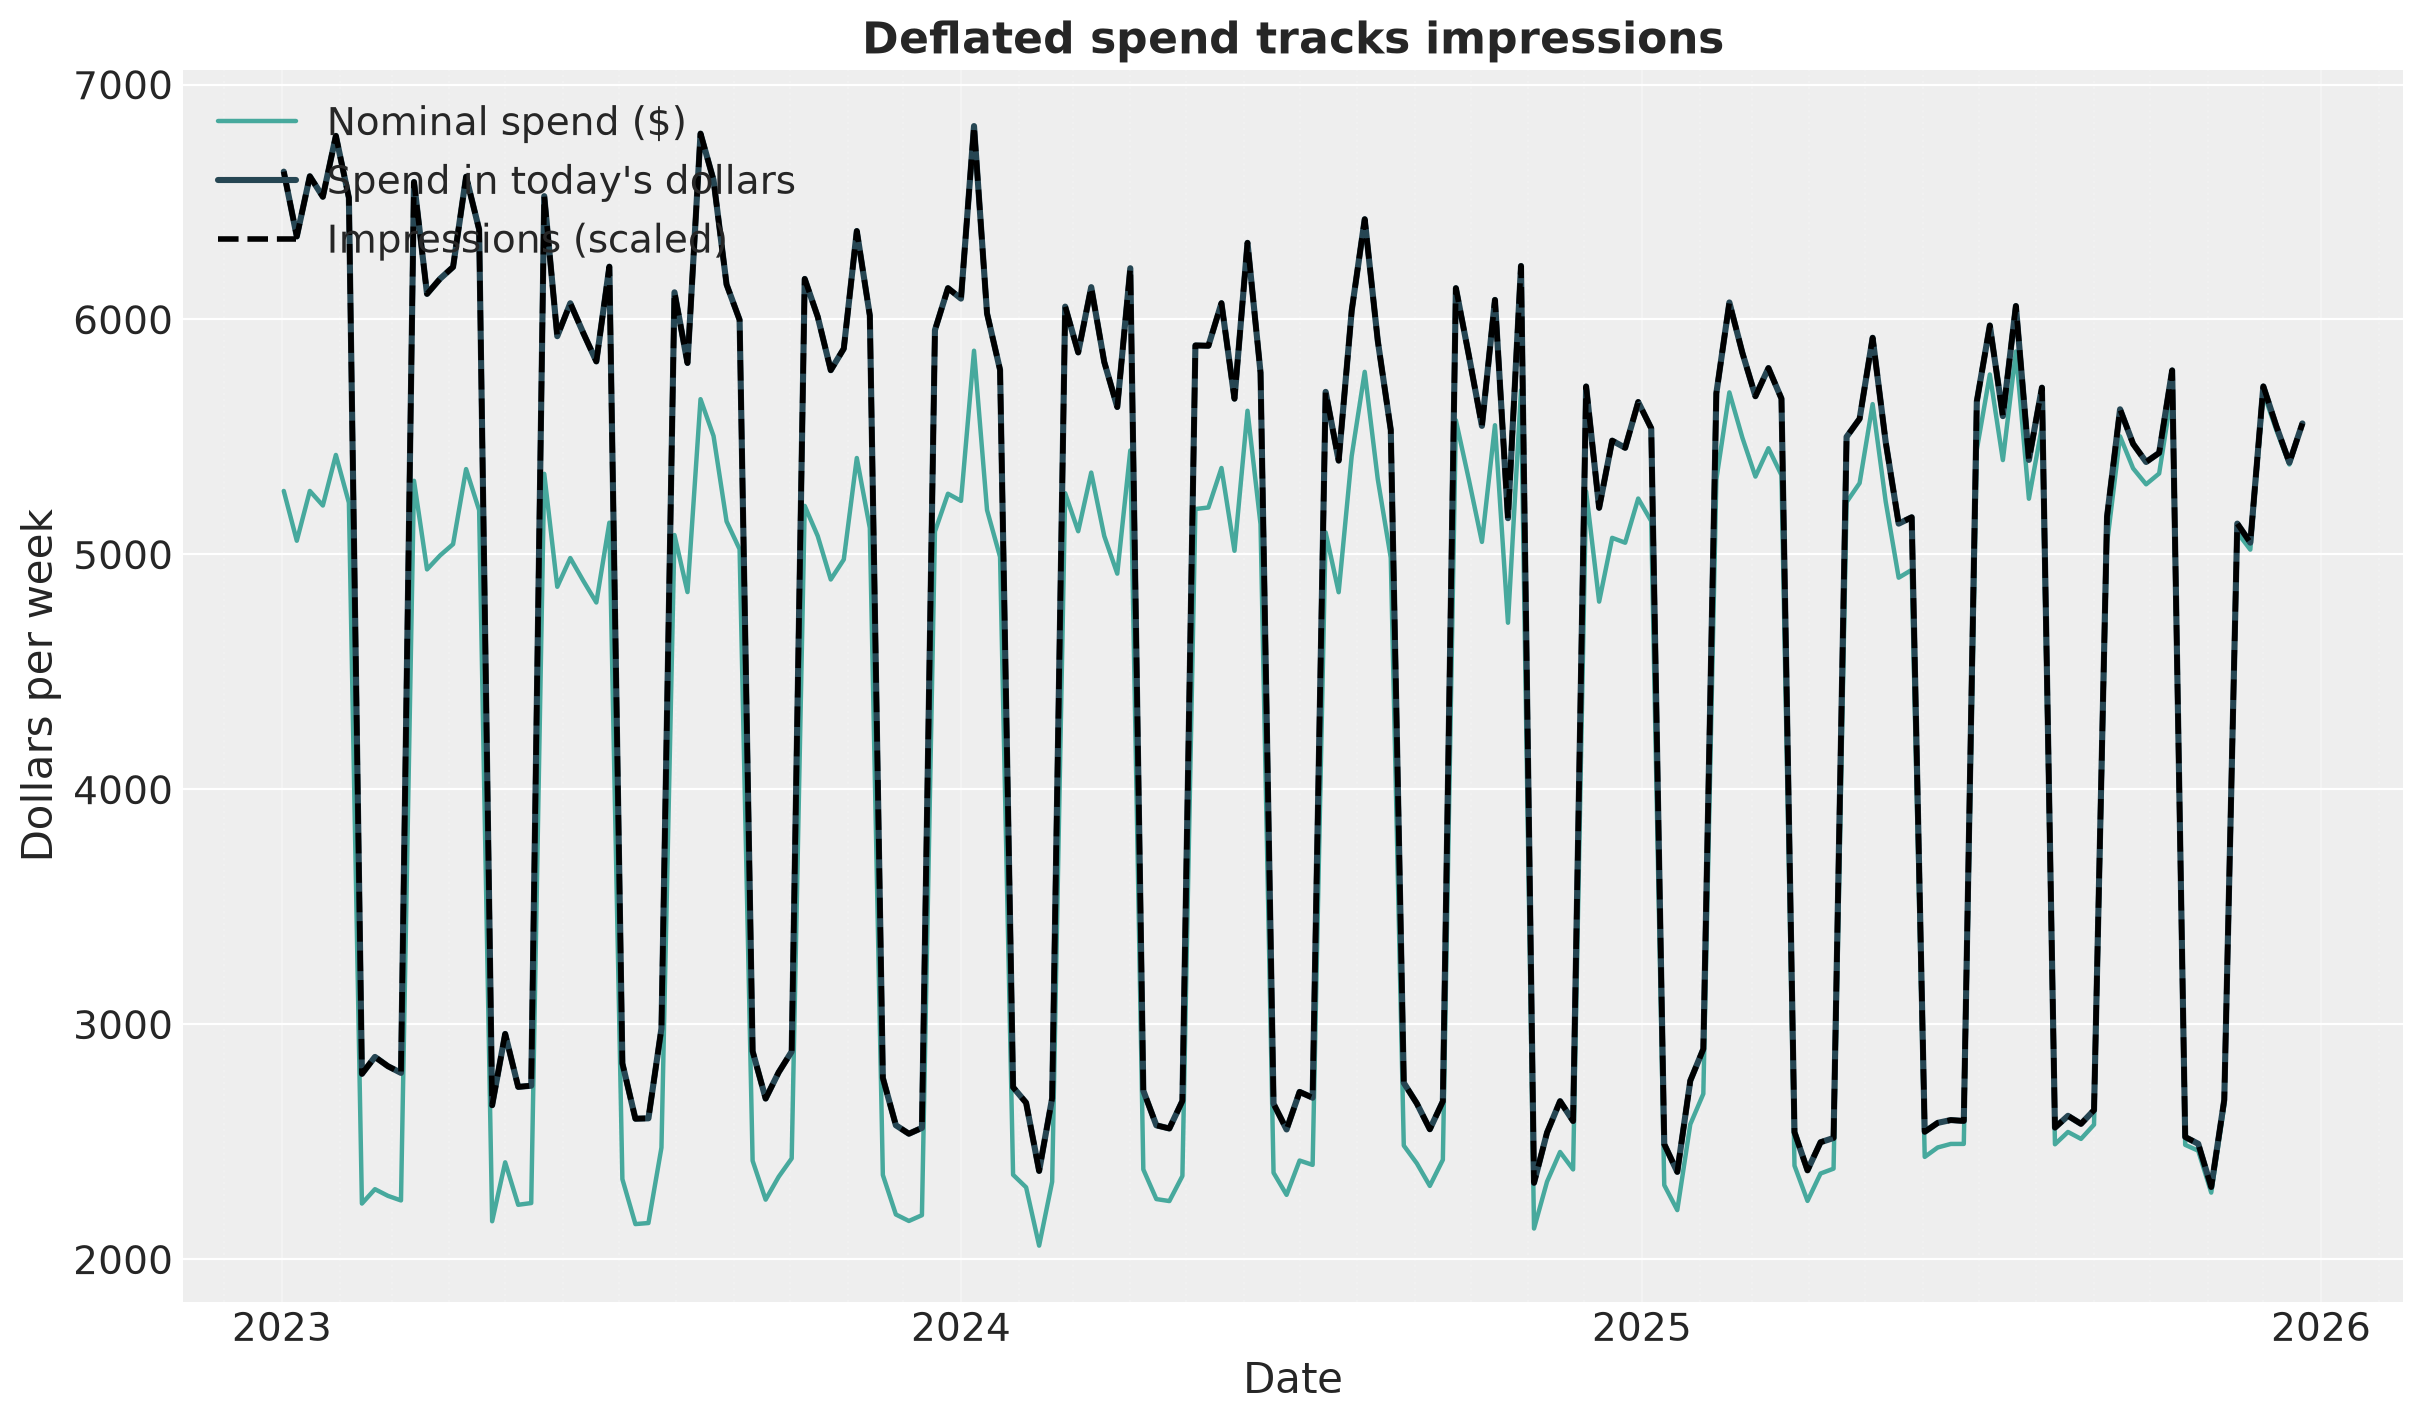

In [14]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
scale = X_today[CHANNEL].mean() / df["impressions"].mean()
ax.plot(
    df["date"],
    X_nominal[CHANNEL],
    color=COLOR_SPEND,
    linewidth=1.6,
    alpha=0.85,
    label="Nominal spend ($)",
)
ax.plot(
    df["date"],
    X_today[CHANNEL],
    color=COLOR_MEDIA,
    linewidth=2.2,
    label="Spend in today's dollars",
)
ax.plot(
    df["date"],
    df["impressions"] * scale,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="Impressions (scaled)",
    zorder=5,
)
ax.set_xlabel("Date")
ax.set_ylabel("Dollars per week")
ax.legend(loc="upper left")
ax.set_title("Deflated spend tracks impressions", fontsize=16, fontweight="bold")
style_date_axis(ax)
plt.show()

In [15]:
mmm_today = fit_mmm(X_today, y)
ds_today = mmm_today.compute_counterfactual_contributions_dataset()

NUTS[nutpie]: [delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, y_sigma]


Output()

Output()

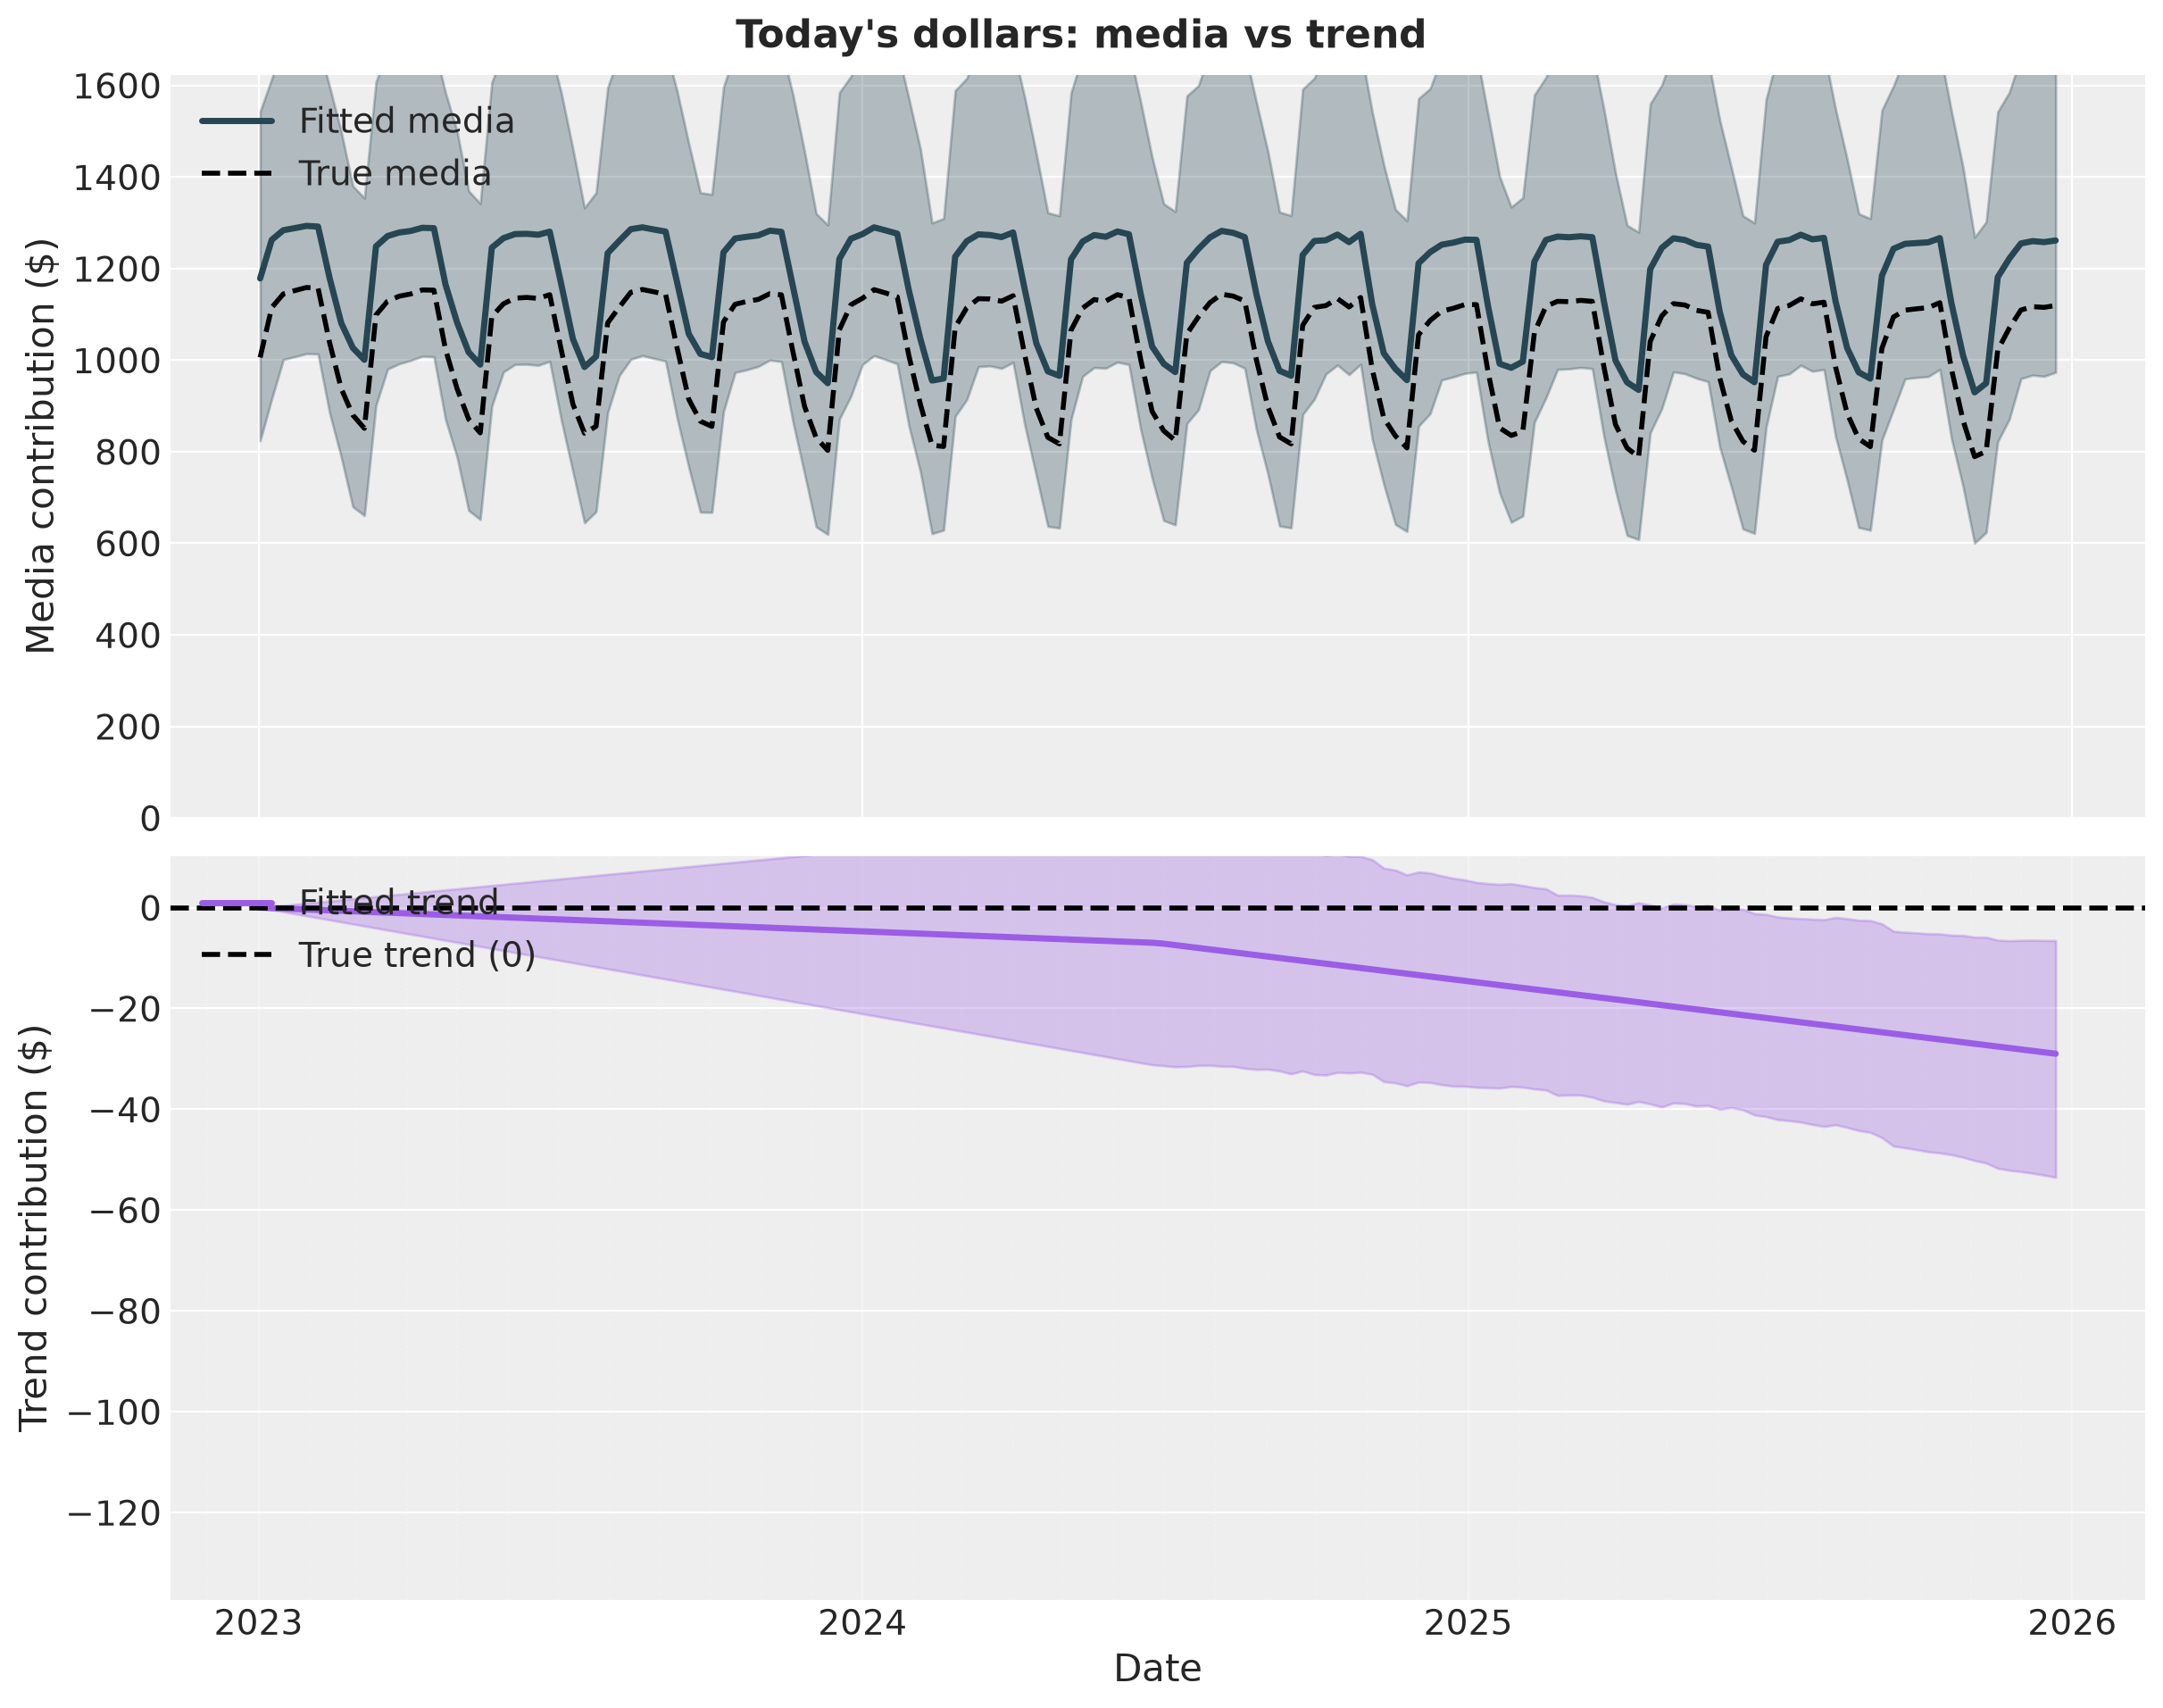

(<Figure size 1200x945 with 2 Axes>,
 array([<Axes: ylabel='Media contribution ($)'>,
        <Axes: xlabel='Date', ylabel='Trend contribution ($)'>],
       dtype=object))

In [16]:
plot_media_vs_trend(
    ds_today,
    df["date"],
    df["media_true"],
    ylim_media,
    ylim_trend,
    title="Today's dollars: media vs trend",
)

**Caption:** Posterior mean and 94% HDI for media (top) and `LinearTrend` (bottom) after deflating spend to the last sample date. Same y-limits as the nominal-spend contribution figure. Black dashed: planted media contribution and true trend of zero.


After deflation, fitted media **tracks the weekly shape** of the planted series, including flighting and the gentle decline in delivery, and the trend is a smaller leftover rather than a story about decline. Level recovery is approximate: the lesson is removing **secular misattribution** (the wrong slope), not claiming oracle precision on the average.


## Comparison

Both models on shared axes. Entity is the component; preprocessing is the line. Lighter bands are the nominal-spend fit; darker bands are today's dollars.


**Caption:** Media (top) and trend (bottom) posterior mean and 94% HDI under nominal spend vs today's dollars, against planted media and a true trend of zero (black dashed). Media panel y-axis starts at zero.


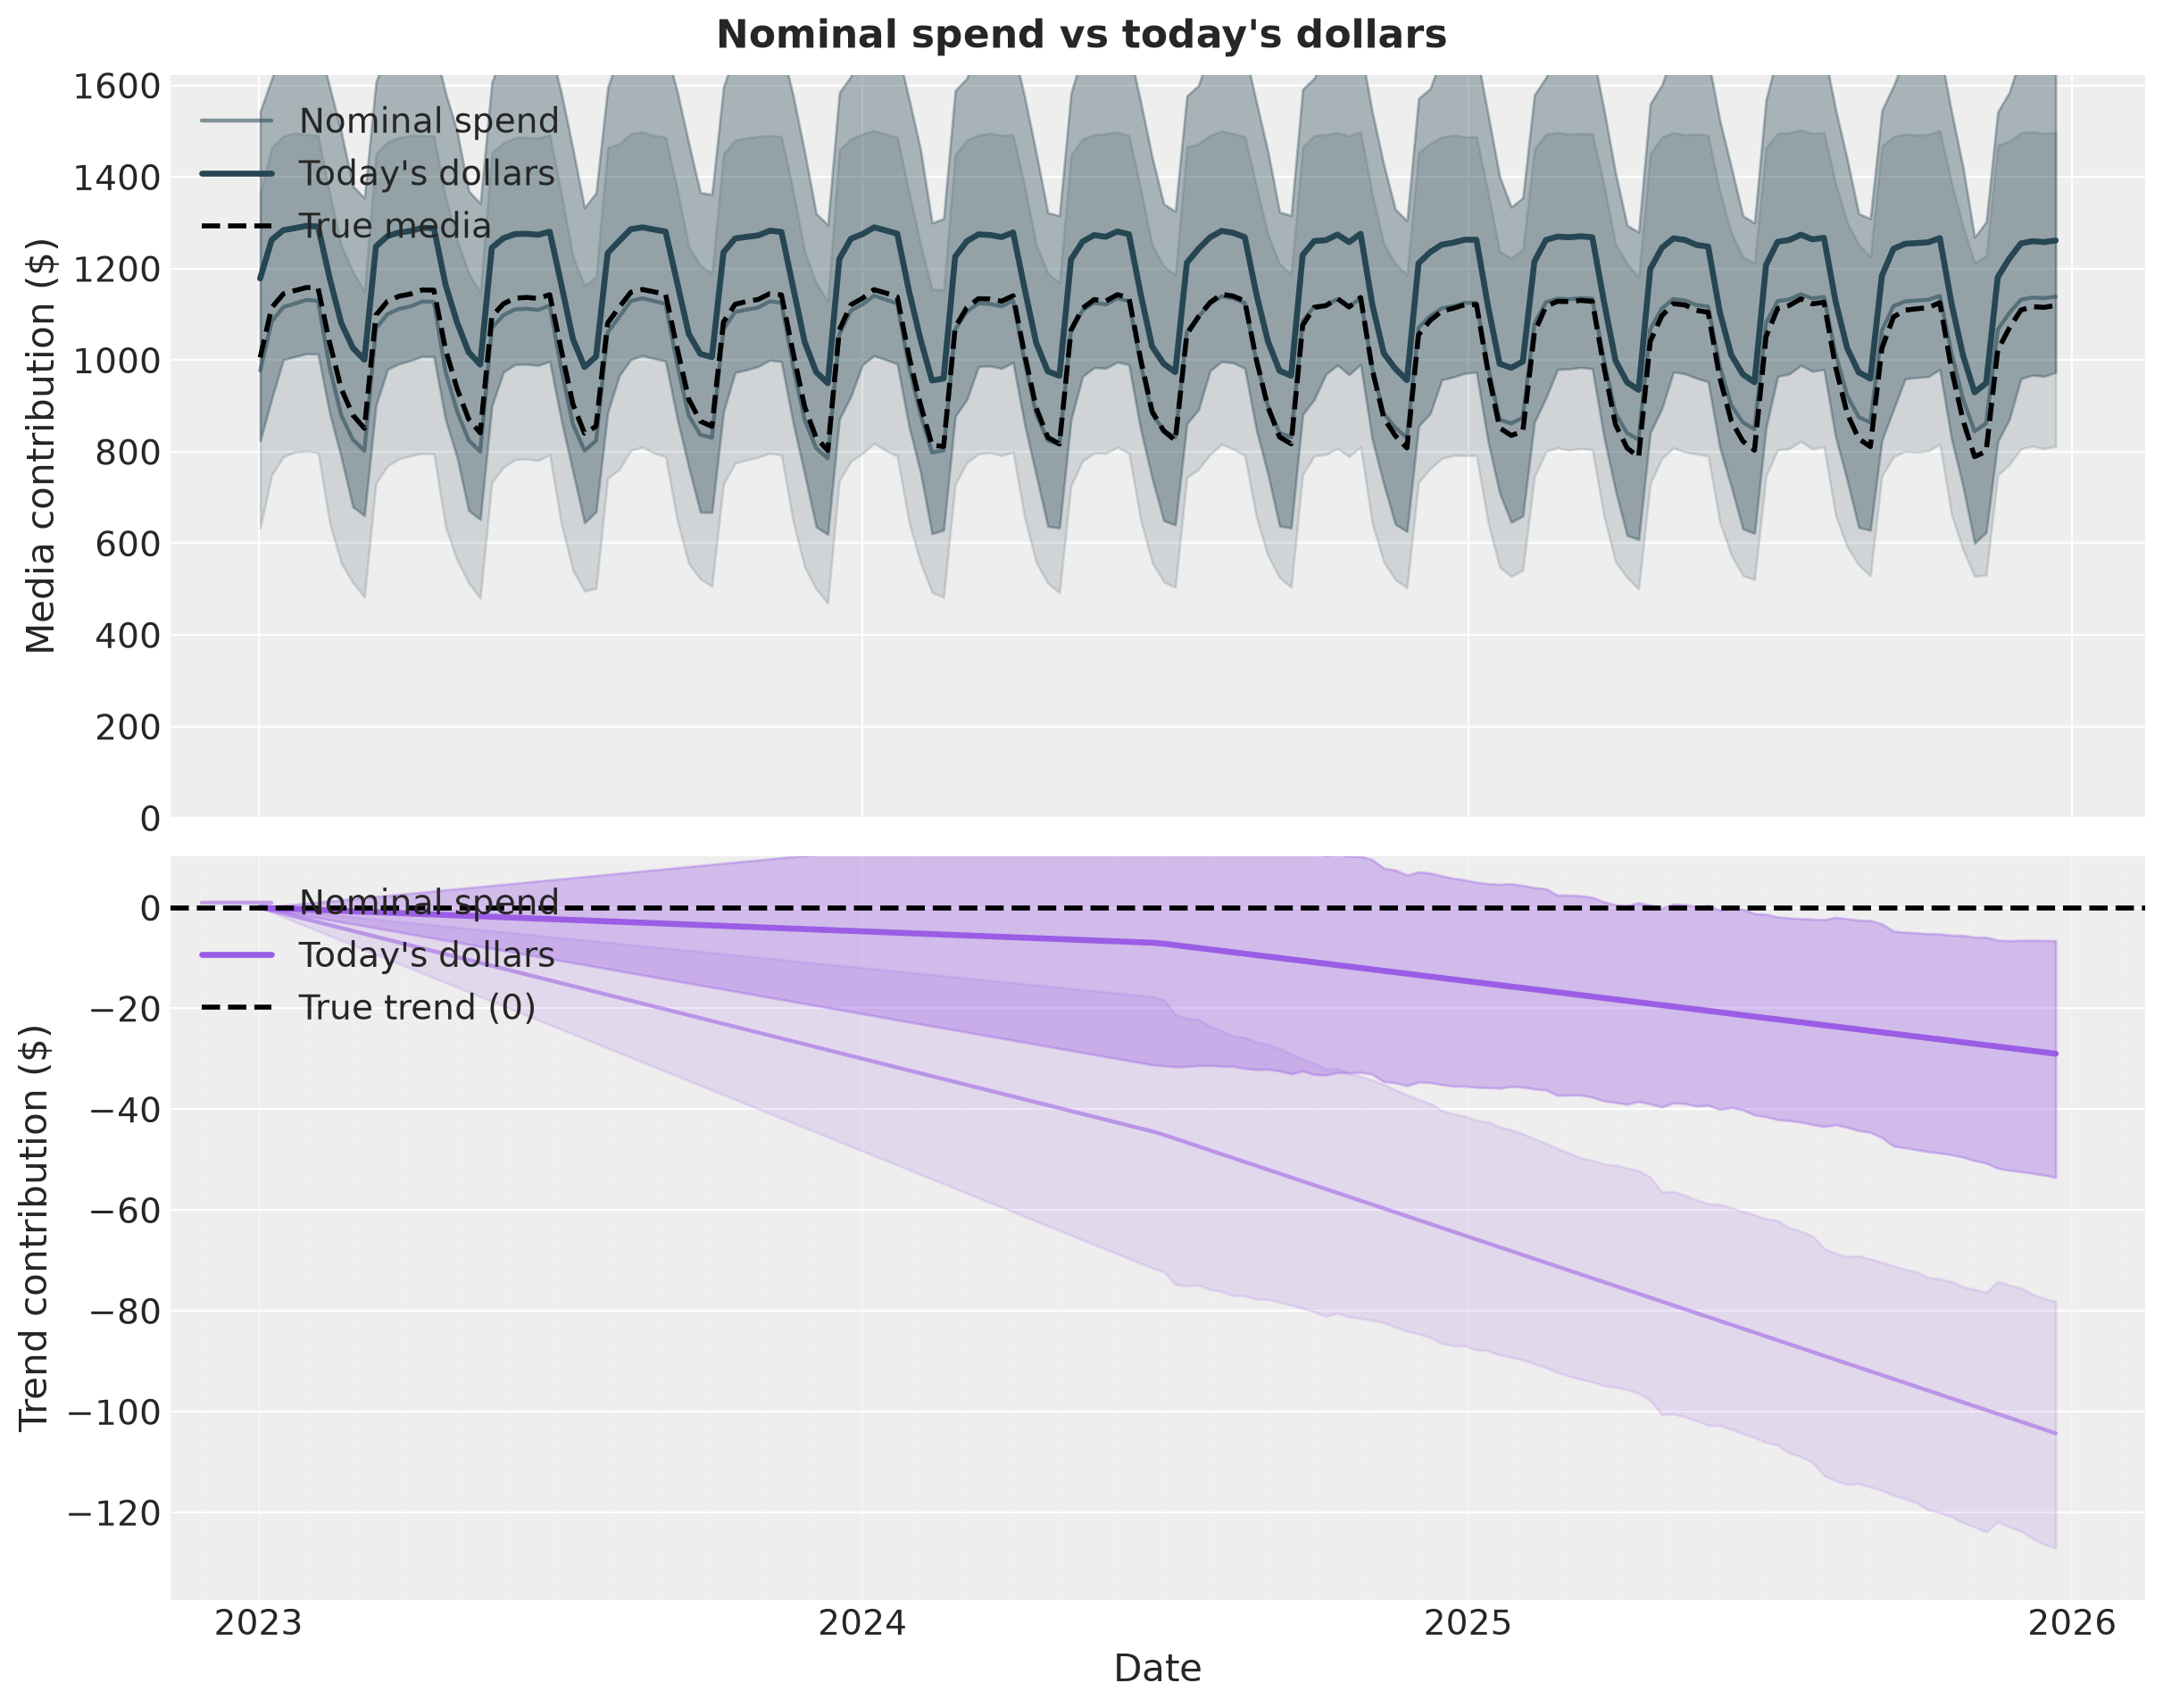

In [17]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
    sharex=True,
)

variants = [
    (ds_nominal, "Nominal spend", 0.15, 1.6, 0.55),
    (ds_today, "Today's dollars", 0.35, 2.4, 1.0),
]
for ds, label, alpha, lw, line_alpha in variants:
    plot_posterior_band(
        axes[0],
        df["date"],
        ds[CHANNEL],
        COLOR_MEDIA,
        label,
        alpha=alpha,
        linewidth=lw,
        line_alpha=line_alpha,
    )

axes[0].plot(
    df["date"],
    df["media_true"],
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="True media",
    zorder=5,
)
axes[0].set_ylabel("Media contribution ($)")
axes[0].legend(loc="upper left")
axes[0].set_ylim(ylim_media)

for ds, label, alpha, lw, line_alpha in variants:
    plot_posterior_band(
        axes[1],
        df["date"],
        ds["trend_effect"],
        COLOR_TREND,
        label,
        alpha=alpha,
        linewidth=lw,
        line_alpha=line_alpha,
    )

axes[1].axhline(
    0.0, color="black", linestyle="--", linewidth=2.0, label="True trend (0)", zorder=5
)
axes[1].set_ylabel("Trend contribution ($)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left")
axes[1].set_ylim(ylim_trend)
style_date_axis(axes[1])

fig.suptitle("Nominal spend vs today's dollars", fontsize=16, fontweight="bold")
plt.show()

In [18]:
years = df["date"].dt.year
comparison = pd.DataFrame(
    {
        "true_media": df.groupby(years)["media_true"].mean(),
        "nominal_media": mean_by_year(ds_nominal[CHANNEL], df["date"]),
        "nominal_trend": mean_by_year(ds_nominal["trend_effect"], df["date"]),
        "today_media": mean_by_year(ds_today[CHANNEL], df["date"]),
        "today_trend": mean_by_year(ds_today["trend_effect"], df["date"]),
    }
)
comparison.index.name = "year"
comparison.round(1)

,true_media,nominal_media,nominal_trend,today_media,today_trend
year,,,,,
2023,1043.4,1014.5,-14.7,1186.7,-2.3
2024,1029.8,1027.0,-46.3,1173.5,-8.4
2025,1010.8,1035.0,-85.1,1156.0,-21.9


Mean weekly contribution by year. Under nominal spend, attributed media drifts **up** while planted media drifts **down**; the trend falls to cancel. The yearly *average* of nominal media can still land near the true average (right for the wrong reasons). After deflation, media follows the gentle decline in delivery and the trend leftover shrinks.

This is preprocessing, not a hidden MMM switch. Both models share adstock, saturation, seasonality, and `LinearTrend`. Only the units of $X$ changed.


## Sensitivity: how much deflation?

You rarely know the true inflation rate. Nominal spend (0% of the index) and full deflation (100%) bracket the range. The table adds a 50% scenario: applying half the estimated drift, as if your benchmark understated CPM growth.


In [19]:
def deflate_spend(scale: float) -> pd.DataFrame:
    years_elapsed = np.arange(n_weeks) / WEEKS_PER_YEAR
    full_index = (1.0 + ANNUAL_CPM_INFLATION) ** (years_elapsed - years_elapsed[-1])
    index = 1.0 + scale * (full_index - 1.0)
    out = X_nominal.copy()
    out[CHANNEL] = X_nominal[CHANNEL] / index
    return out


true_media_slope = half_window_slope(df["media_true"].to_numpy())

mmm_half = fit_mmm(deflate_spend(0.5), y)
ds_half = mmm_half.compute_counterfactual_contributions_dataset()

sensitivity = pd.DataFrame(
    {
        "deflation_share": [0.0, 0.5, 1.0],
        "media_slope": [
            half_window_slope(ds_nominal[CHANNEL].mean(("chain", "draw"))),
            half_window_slope(ds_half[CHANNEL].mean(("chain", "draw"))),
            half_window_slope(ds_today[CHANNEL].mean(("chain", "draw"))),
        ],
        "trend_slope": [
            half_window_slope(ds_nominal["trend_effect"].mean(("chain", "draw"))),
            half_window_slope(ds_half["trend_effect"].mean(("chain", "draw"))),
            half_window_slope(ds_today["trend_effect"].mean(("chain", "draw"))),
        ],
        "mean_media": [
            mean_by_year(ds_nominal[CHANNEL], df["date"]).mean(),
            mean_by_year(ds_half[CHANNEL], df["date"]).mean(),
            mean_by_year(ds_today[CHANNEL], df["date"]).mean(),
        ],
    }
)
print(f"Planted media slope (2nd half − 1st): {true_media_slope:.1f}")
sensitivity.round(1)

NUTS[nutpie]: [delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, y_sigma]


Output()

Output()

Planted media slope (2nd half − 1st): -27.2


,deflation_share,media_slope,trend_slope,mean_media
0,0.0,12.8,-52.5,1025.5
1,0.5,-4.9,-34.6,1229.5
2,1.0,-25.1,-14.6,1172.1


Read **media_slope** and **trend_slope** first. Full deflation should pull media slope toward the planted decline and shrink the cancelling trend. **mean_media** can look closer to truth under nominal spend; that average is not identification. Treat the index as a **sensitivity exercise**, not a single correct answer.


## Summary

- Nominal spend can rise while impressions fall if CPM outpaces budget growth, a common pattern when auction inflation beats annual uplifts.
- An MMM with time-invariant saturation on those dollars will typically **raise media contribution with spend** and dump the leftover into a flexible trend, even while **true** media is falling with delivery. A Hilbert-space GP intercept would soak up the same drift even more easily.
- If you have impressions or GRPs, fit those and report in dollars with {ref}`mmm_cost_per_unit`.
- If you only have spend, deflate with a smooth external index *before* `fit`, and run sensitivity on the index.
- `set_cost_per_unit` on a spend-fitted model does not fix attribution; it only changes ROAS denominators.
- Do not use time-varying media as an inflation sponge.

**Next steps.** The same unit drift matters for **long-horizon budget optimisation and scenario planning** (future dollars buy fewer ads too), but that is out of scope here.

```{note}
Long-horizon optimisation and scenario planning should use a *future* cost-per-unit (or a deflated decision variable), not last year's nominal dollars. That workflow is a different notebook; this one stops at attribution.
```

**Reflection.** In your last two or three years, did CPMs or cost-per-GRP trend up faster than your budget? If you only have spend, what would a simple annual index do to your media-vs-trend *slopes*, not just the averages? Paid-social auctions often show this drift in the open; TV cost-per-GRP can move the same way more quietly.


In [20]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Wed, 02 Sep 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.1.0

arviz         : 1.2.0
graphviz      : 0.21
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 2.3.3
pymc_marketing: 1.1.0

Watermark: 2.6.0

